# Clasificación del Iris Dataset: LDA, Naive Bayes y k-NN

**Objetivo:** entrenar y comparar tres modelos de clasificación sobre el *Iris dataset*.

| Elemento | Configuración |
|---|---|
| Modelos | LDA (`LinearDiscriminantAnalysis`), Naive Bayes gaussiano (`GaussianNB`), k-NN (`KNeighborsClassifier`) |
| Partición | 60 % entrenamiento / 40 % prueba (estratificada) |
| Validación | k-fold cross-validation (`StratifiedKFold`, k = 5) sobre el conjunto de entrenamiento |
| Salidas | fronteras de decisión, métricas de clasificación y matriz de confusión |


## 1. Importaciones y configuración

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
N_SPLITS = 5
N_NEIGHBORS = 5
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## 2. Carga y exploración rápida de los datos

In [108]:
iris = load_iris(as_frame=True)
X = iris.data                     # 4 características
y = iris.target                   # 0=setosa, 1=versicolor, 2=virginica
feature_names = list(X.columns)
class_names = list(iris.target_names)

df = X.copy()
df["species"] = pd.Categorical.from_codes(y, class_names)
print(f"Muestras: {df.shape[0]}  |  Características: {len(feature_names)}  |  Clases: {class_names}")
print("\nDistribución de clases:")
print(df["species"].value_counts())
df.head()

Muestras: 150  |  Características: 4  |  Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Distribución de clases:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


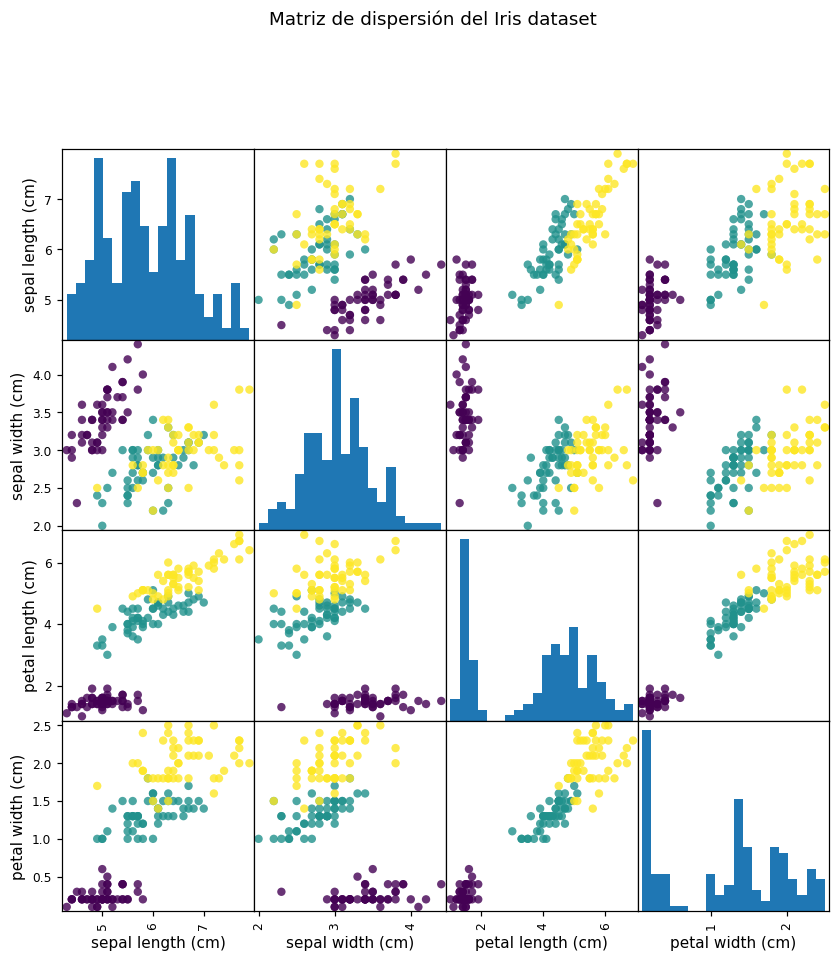

In [109]:
# Dispersión por pares de características, coloreado por especie
pd.plotting.scatter_matrix(
    df[feature_names],
    c=y,
    figsize=(9, 9),
    marker="o",
    hist_kwds={"bins": 20},
    s=30,
    alpha=0.8,
)
plt.suptitle("Matriz de dispersión del Iris dataset", y=1.02)
plt.show()

## 3. Partición 60 / 40 (estratificada)

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0] / len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0] / len(X):.0%})")
print("\nProporción de clases (train):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3).to_string())
print("\nProporción de clases (test):")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3).to_string())

Entrenamiento: 90 muestras (60%)
Prueba:        60 muestras (40%)

Proporción de clases (train):
target
0    0.333
1    0.333
2    0.333

Proporción de clases (test):
target
0    0.333
1    0.333
2    0.333


## 4. Definición de los modelos

Cada modelo se envuelve en un `Pipeline` con `StandardScaler`. El escalado es indiferente para LDA y GaussianNB, pero es clave para k-NN (distancias).

In [111]:
models = {
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]),
    f"k-NN (k={N_NEIGHBORS})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=N_NEIGHBORS)),
    ]),
}
models

{'LDA': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearDiscriminantAnalysis())]),
 'Naive Bayes': Pipeline(steps=[('scaler', StandardScaler()), ('clf', GaussianNB())]),
 'k-NN (k=5)': Pipeline(steps=[('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])}

## 5. k-fold cross-validation (sobre el conjunto de entrenamiento)

Se usa `StratifiedKFold` con k = 5. La CV sólo toca los datos de entrenamiento; el conjunto de prueba se reserva para la evaluación final.

In [112]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_rows.append({
        "Modelo": name,
        "Accuracy media": scores.mean(),
        "Desv. est.": scores.std(),
        "Folds": np.round(scores, 3).tolist(),
    })

cv_results = pd.DataFrame(cv_rows).set_index("Modelo")
cv_results.round(4)

,Accuracy media,Desv. est.,Folds
Modelo,,,
LDA,0.9667,0.0272,"[0.944, 0.944, 1.0, 0.944, 1.0]"
Naive Bayes,0.9556,0.0416,"[1.0, 0.944, 1.0, 0.944, 0.889]"
k-NN (k=5),0.9333,0.0222,"[0.944, 0.944, 0.944, 0.944, 0.889]"


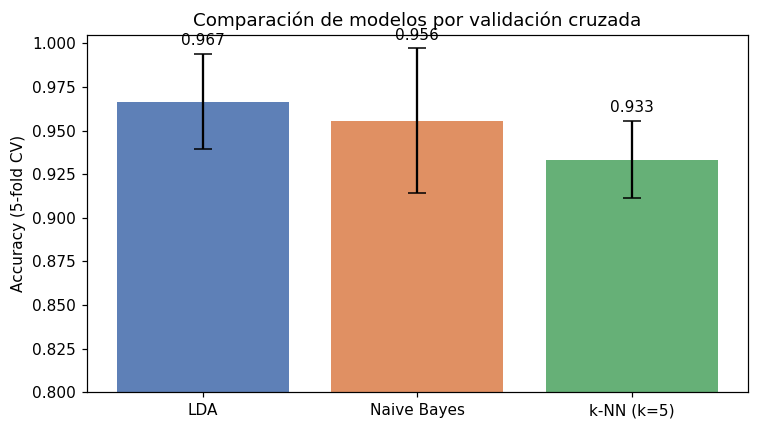

In [113]:
# Visualización de la CV: media +/- desviación estándar
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    cv_results.index,
    cv_results["Accuracy media"],
    yerr=cv_results["Desv. est."],
    capsize=6,
    color=["#4C72B0", "#DD8452", "#55A868"],
    alpha=0.9,
)
ax.set_ylim(0.8, 1.005)
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("Comparación de modelos por validación cruzada")
for i, (m, s) in enumerate(zip(cv_results["Accuracy media"], cv_results["Desv. est."])):
    ax.text(i, m + s + 0.005, f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Entrenamiento final y métricas sobre el conjunto de prueba

In [114]:
fitted = {}
test_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(f"Modelo: {name}")
    print("=" * 60)
    print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    test_summary.append({
        "Modelo": name,
        "Accuracy": report["accuracy"],
        "Precision (macro)": report["macro avg"]["precision"],
        "Recall (macro)": report["macro avg"]["recall"],
        "F1 (macro)": report["macro avg"]["f1-score"],
    })

pd.DataFrame(test_summary).set_index("Modelo").round(4)

Modelo: LDA
Accuracy en prueba: 0.9833

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.95      1.00      0.98        20
   virginica       1.00      0.95      0.97        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

Modelo: Naive Bayes
Accuracy en prueba: 0.9333

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.86      0.95      0.90        20
   virginica       0.94      0.85      0.89        20

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60

Modelo: k-NN (k=5)
Accuracy en prueba: 0.9167

Reporte de clasificación:
              precision  

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
LDA,0.9833,0.9841,0.9833,0.9833
Naive Bayes,0.9333,0.9360,0.9333,0.9332
k-NN (k=5),0.9167,0.9224,0.9167,0.9162


## 7. Matrices de confusión (conjunto de prueba)

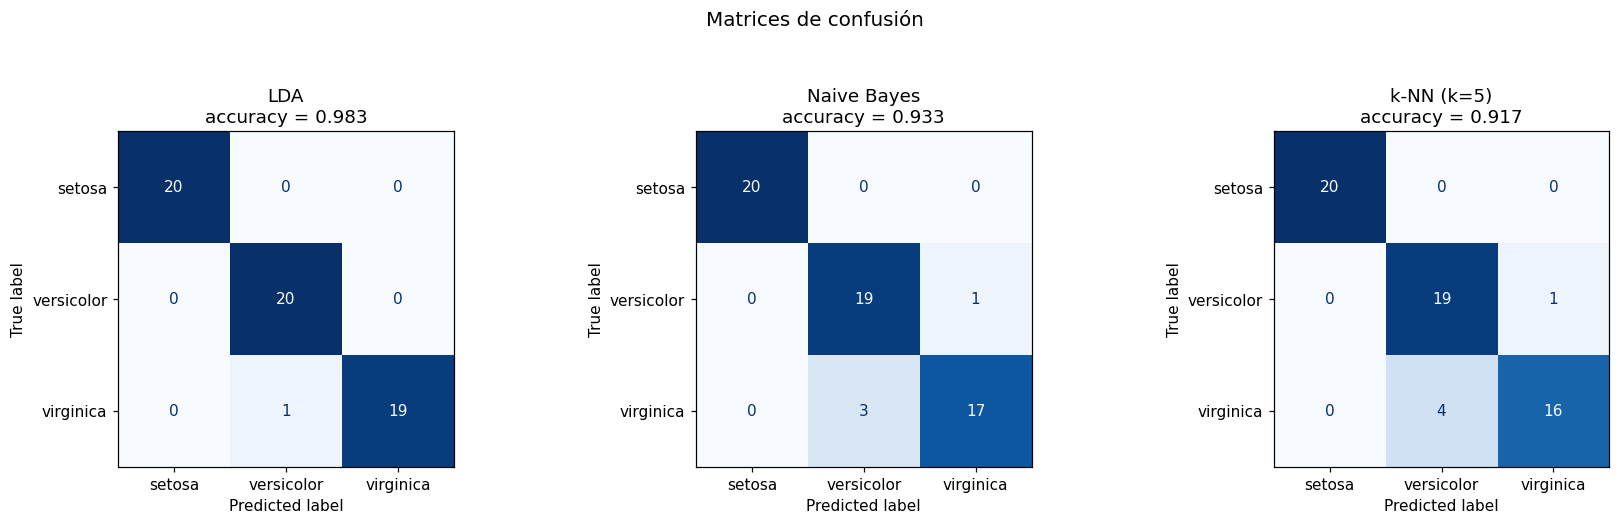

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, model) in zip(axes, fitted.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{name}\naccuracy = {accuracy_score(y_test, y_pred):.3f}")

plt.suptitle("Matrices de confusión", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Fronteras de decisión

Las fronteras de decisión sólo pueden dibujarse en 2D. Se reentrena cada modelo usando las dos características más discriminantes: **petal length** y **petal width**. Los puntos son el conjunto de prueba.

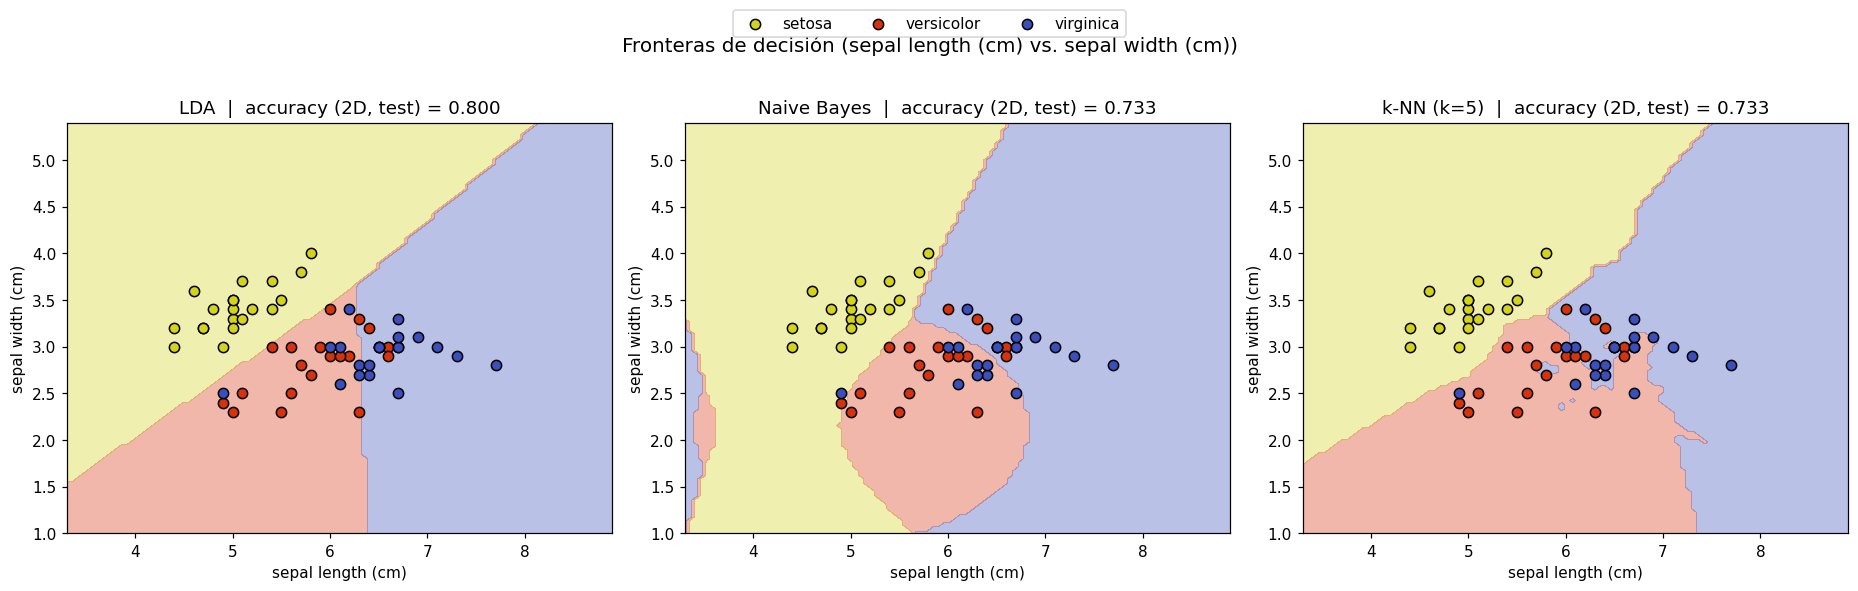

In [119]:
# Par de características para visualizar en 2D (descomenta el que quieras)
pair = ["petal length (cm)", "petal width (cm)"]
pair = ["sepal length (cm)", "sepal width (cm)"]

X_train_2d = X_train[pair]
X_test_2d = X_test[pair]

models_2d = {
    "LDA": Pipeline([("scaler", StandardScaler()), ("clf", LinearDiscriminantAnalysis())]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
    f"k-NN (k={N_NEIGHBORS})": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=N_NEIGHBORS))]),
}

class_colors = ["#D3D31D", "#D5320D", "#3A4EBC"]  # setosa, versicolor, virginica

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, models_2d.items()):
    model.fit(X_train_2d, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_2d))

    # multiclass_colors evita el UserWarning de 'cmap' en el caso multiclase (sklearn >= 1.7)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_2d,
        response_method="predict",
        alpha=0.35,
        multiclass_colors=class_colors,
        ax=ax,
        xlabel=pair[0],
        ylabel=pair[1],
    )

    y_test_arr = y_test.to_numpy()
    X_test_arr = X_test_2d.to_numpy()
    for cls, color in enumerate(class_colors):
        mask = y_test_arr == cls
        ax.scatter(
            X_test_arr[mask, 0], X_test_arr[mask, 1],
            color=color, edgecolor="k", s=45, label=class_names[cls],
        )
    ax.set_title(f"{name}  |  accuracy (2D, test) = {acc:.3f}")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.suptitle(f"Fronteras de decisión ({pair[0]} vs. {pair[1]})", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 9. Conclusiones

- Las tres familias de modelos alcanzan una precisión alta en Iris porque las clases (sobre todo *setosa*) están casi linealmente separadas en el espacio de pétalos.
- **LDA** produce fronteras lineales; **GaussianNB** fronteras cuadráticas suaves (asume independencia entre características); **k-NN** fronteras locales e irregulares, sensibles a `k` y al escalado.
- La validación cruzada de 5 folds sobre el conjunto de entrenamiento confirma que las diferencias entre modelos son pequeñas y están dentro de una desviación estándar.
- La confusión residual se concentra entre *versicolor* y *virginica*, que se solapan parcialmente.